## Precession 

(NOTE IT WILL BE IN UNITS OF radians/pc from the previous choice of natural units)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import csv 
import scipy.fftpack
from imripy import merger_system as ms
from imripy import halo
from imripy import waveform, detector
import time
import pandas as pd
import dask.dataframe as dd

#local maxima and minima finder 
from scipy.signal import argrelmin as amin
from scipy.signal import argrelmax as amax

In [2]:
t_i_1 = time.perf_counter()
data = pd.read_csv('Precession_on_1k_dp_1000_onlyPN.csv',header=None, usecols=[0,1,2,3,4]) 
#Precession_on_1k_dp_1000_onlyPN.csv
#Precession_on_1k_dp_1000.csv
r    = (data.values[:,0])                              #Initializing empty array which will hold the r Values
phi  = (data.values[:,1])                              #Initializing empty array which will hold the phi Values
dr   = (data.values[:,2])                              #Initializing empty array which will hold the dr Values
dphi = (data.values[:,3])                              #Initializing empty array which will hold the dphi Values
t    = (data.values[:,4])  

print(len(r))
t_f_2 = time.perf_counter() - t_i_1
print("elapsed time ", t_f_2)

1000000
elapsed time  0.7652827000000002


## Radial Plot

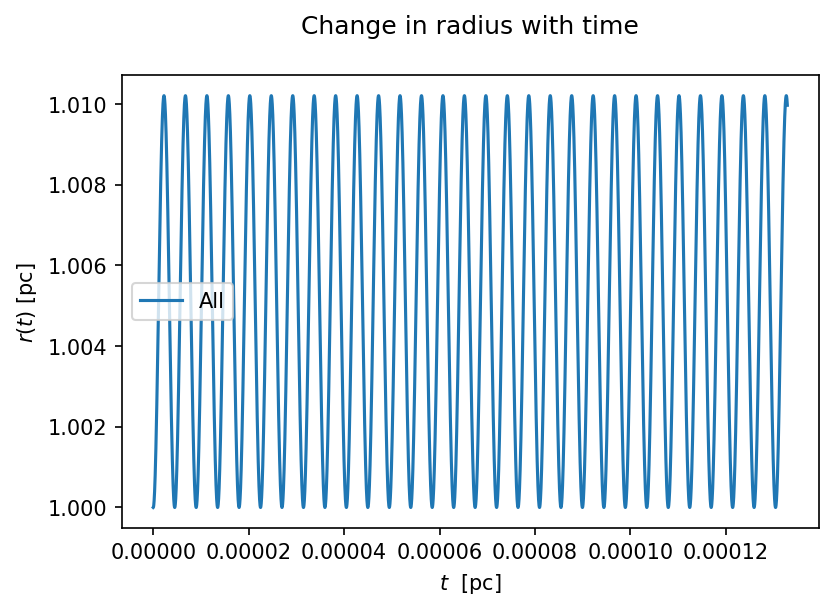

In [3]:
%matplotlib inline
#----------------------------------------------------------------------
r0 = 2.88e-8
r_start = 0
r_end = len(r)-970000

#---------------------------------------------------------------------
fig = plt.figure(figsize=(6,4), dpi=150)
plt.plot(t[r_start:r_end], r[r_start:r_end]/r0, label="All")
plt.title("Change in radius with time",pad=20)
plt.legend(loc=0)
#plt.axis('equal')
plt.xlabel("$t$  [pc]")
plt.ylabel("$r(t)$ [pc]")
plt.show()

In [4]:
#Getting the indeces of minima and maxima from r(t)
indeces_min = amin(r)
indeces_max = amax(r)

## Plotting these minima and maxima

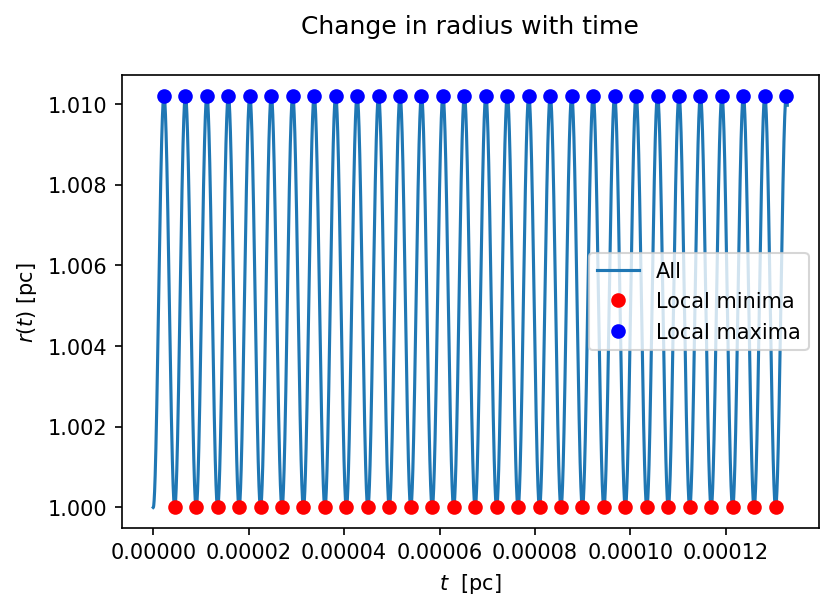

In [5]:
r0 = 2.88e-8
r_start = 0
r_end = len(r)-970000

#---------------------------------------------------------------------
fig = plt.figure(figsize=(6,4), dpi=150)
plt.plot(t[r_start:r_end], r[r_start:r_end]/r0, label="All")
plt.plot(t[indeces_min[0][np.where(indeces_min[0] < r_end)]],r[indeces_min[0][np.where(indeces_min[0] < r_end)]]/r0,'ro',label='Local minima')
plt.plot(t[indeces_max[0][np.where(indeces_max[0] < r_end)]],r[indeces_max[0][np.where(indeces_max[0] < r_end)]]/r0,'bo',label='Local maxima')
plt.title("Change in radius with time",pad=20)
plt.legend(loc=0)
#plt.axis('equal')
plt.xlabel("$t$  [pc]")
plt.ylabel("$r(t)$ [pc]")
plt.show()

## Getting Precession as:
Precession $= \frac{2\psi- 2\pi}{T}$ (radians precessed per orbit) 

Where $\psi$ is the Perihelion angle difference between orbits, and $T$ is the period of one orbit (Page 10).

https://www.math.toronto.edu/~colliand/426_03/Papers03/C_Pollock.pdf

In [6]:
#Periof of an orbit, basically t[i+1] - t[i] with i being an index from local maxima or minima
T = np.average(np.gradient(t[indeces_min]))

#psi computed from the document 'experimentally' from page 10
psi = (2*np.abs(phi[indeces_min]-(phi[indeces_max])[0:len(phi[indeces_min])] )-2*np.pi) / T
avg_psi = np.average(psi)
print ('average precession (from orbits): ',  avg_psi,  '[radians/pc]')

average precession (from orbits):  6969.544199511846 [radians/pc]


In [7]:
#-------------------------System Parameters------------------------------------
m1 = 4.8e-11
m2 = 4.8e-14
D  = 1e5 
a0 = 2.88e-8
e0 = 0.

#---------------------------Mass Arrays-----------------------------------------
m_total = m1+m2
mu = (m1*m2)/(m1+m2)
mass=[m1,m2,m_total,mu]

## Precession from theoretical formula:

Just before equation 8 in this paper:

https://arxiv.org/pdf/1102.5192.pdf


In [8]:
#Since I have access to the max and min radius in each orbit through indeces, I might as well use the alternative formulas for a and e:
a = (r[indeces_min]+r[indeces_max][0:len(phi[indeces_min])])/2
e=1-r[indeces_min][0]/a

#Theoretical precession formula from the paper
f_b = np.sqrt(m_total/a**3)/(2*np.pi)
dw_dt = np.average(6* np.pi * f_b* m_total / (a*(1-e**2)))   #taking an average value

print ('average (theoretical) precession: ',  dw_dt,  '[radians/pc]')

average (theoretical) precession:  7008.670610706303 [radians/pc]


## Some comments:

-The precession rate should be constant, and I averaged the both of the theoretical and "experimental" (just the precession taken directly from the orbits). Not sure how big of a good approximation this could be. 

-This precession does seem to oscillate over each orbit (for the one extracted from the orbits), I'm not sure why, here's a plot of the precession psi as a function of time:

Text(0, 0.5, '$r(t)$ [pc]')

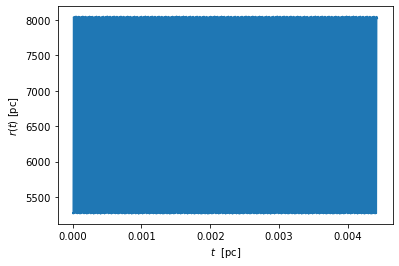

In [12]:
plt.plot(t[indeces_min],psi)
plt.xlabel("$t$  [pc]")
plt.ylabel("Precession [rad/pc]")

Whereas the theoretical precession remains as a relatively flat line in comparison 

Text(0, 0.5, 'Precession [rad/pc]')

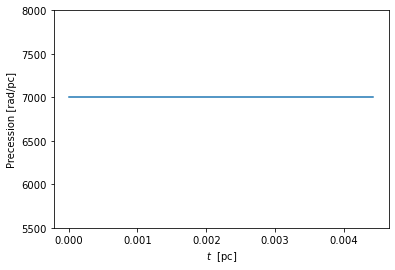

In [16]:
plt.plot(t[indeces_min],6* np.pi * f_b* m_total / (a*(1-e**2)))
plt.ylim([5500,8000])
plt.xlabel("$t$  [pc]")
plt.ylabel("Precession [rad/pc]")